# Q3: Feature Engineering and Regression Pipeline

In this notebook, I build a regression pipeline to predict `items_sold` using engineered features and evaluate model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert date column
# The 'transaction_date' column is currently in string format. Converting it to datetime format allows us to extract useful features like month, day of the week, etc., which can improve our model's performance.

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
# Extracting date features
# Extracting features like year, month, and day of the week from the 'transaction_date' can help capture seasonal patterns and trends in sales, which are crucial for accurate predictions in retail data.

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Custom feature
# Creating a feature to indicate if the transaction date is towards the end of the month, which can be a critical period for retail sales due to pay cycles and end-of-month promotions.

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Time-based features were added to capture seasonality and behavioral patterns.

For example:
- month captures seasonal trends  
- day_of_week captures weekday vs weekend behavior  
- is_month_end may reflect salary cycles or increased spending  

In [4]:
# Remove IDs if present (they don't help prediction)
# The 'store_id' column is an identifier that does not provide predictive value for the model. Removing it helps prevent overfitting and ensures that the model focuses on meaningful features rather than unique identifiers.

df = df.drop(columns=['store_id'], errors='ignore')

# Handle inf values just in case
# In case there are any infinite values in the dataset, we replace them with NaN and then fill those NaN values with the median of the respective columns. This ensures that our model can handle any anomalies in the data without crashing.

df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

In [5]:
# Sorting by date
# Sorting the dataset by 'transaction_date' ensures that our training and testing sets are chronologically ordered, which is important for time series data to prevent data leakage and to better simulate real-world forecasting scenarios.

df = df.sort_values('transaction_date')

# Splitting last 20% as test
# Since this is time series data, we will split the dataset chronologically, using the first 80% of the data for training and the last 20% for testing. This approach helps to mimic real-world conditions where we train on past data and predict future outcomes.

split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

The data was split chronologically rather than randomly.

A time-based split was used instead of a random split to avoid data leakage.

A random split would mix past and future data, which can lead to data leakage and overly optimistic performance.

Using a time-based split better reflects how the model would perform in real-world scenarios.

In [6]:
# is_weekend and is_festival are binary (0/1) flags already in the dataset.
# They are strong predictors of sales volume and must be included.
# Binary columns are numeric — they go into num_cols for StandardScaler.

num_cols = [
    'competition_density',
    'year', 'month', 'day_of_week', 'is_month_end',
    'is_weekend',    # binary flag from original dataset
    'is_festival'    # binary flag from original dataset
]
cat_cols = ['promotion_type', 'location_type', 'store_size']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

In [7]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline as SkPipeline

# Log1p transform + StandardScaler for competition_density (right-skewed feature)
log_scaler = SkPipeline([
    ('log',   FunctionTransformer(np.log1p, validate=False)),
    ('scale', StandardScaler())
])

# Regular StandardScaler for all other numeric features
regular_num_cols = [
    'year', 'month', 'day_of_week', 'is_month_end',
    'is_weekend', 'is_festival'
]
cat_cols = ['promotion_type', 'location_type', 'store_size']

preprocessor = ColumnTransformer([
    ('comp_density', log_scaler,       ['competition_density']),
    ('num',          StandardScaler(), regular_num_cols),
    ('cat',          OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

In [8]:
# Simple baseline: predict mean
# A simple baseline model that predicts the mean of the target variable (items_sold) from the training set. This provides a benchmark to compare our more complex models against.

baseline_pred = np.full(len(test), train['items_sold'].mean())

baseline_rmse = np.sqrt(mean_squared_error(test['items_sold'], baseline_pred))
baseline_mae = mean_absolute_error(test['items_sold'], baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 58.8607769517873
Baseline MAE: 46.24868055555556


The preprocessing pipeline applies:
- **StandardScaler** to all numerical features, including the binary flags
  `is_weekend` and `is_festival` from the original dataset. These binary
  columns are meaningful signals: weekends and festivals significantly
  affect foot traffic and buying behaviour in retail.
- **OneHotEncoder** to categorical features: promotion_type, location_type,
  and store_size.

The pipeline is fitted only on the training set and applied to both train
and test sets, preventing any information from the test set influencing
the preprocessing.

In [9]:
# Train models
# We will train two regression models: Linear Regression and Random Forest Regressor. The Linear Regression model serves as a simple baseline to understand the linear relationships in the data, while the Random Forest Regressor is a more complex model that can capture non-linear relationships and interactions between features, potentially leading to better performance.

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

# We will iterate through each model, create a pipeline that includes the preprocessing steps and the model itself, fit the pipeline on the training data, and then make predictions on the test set. We will evaluate the performance of each model using RMSE and MAE metrics, and store the trained pipelines and predictions in a results dictionary for later analysis and comparison.
for name, model in models.items():
    
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(train.drop('items_sold', axis=1), train['items_sold'])
    
    preds = pipe.predict(test.drop('items_sold', axis=1))
    
    rmse = np.sqrt(mean_squared_error(test['items_sold'], preds))
    mae = mean_absolute_error(test['items_sold'], preds)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    
    results[name] = (pipe, preds)
    
    # For each model, we store the trained pipeline and the predictions in the results dictionary for later analysis and comparison.


Linear Regression
RMSE: 27.1542295732389
MAE: 21.133088846641634

Random Forest
RMSE: 31.808288645443533
MAE: 25.49331944444445


The Linear Regression model performs better than the Random Forest model in this case.

This suggests that the relationship between features and items_sold seems relatively linear.

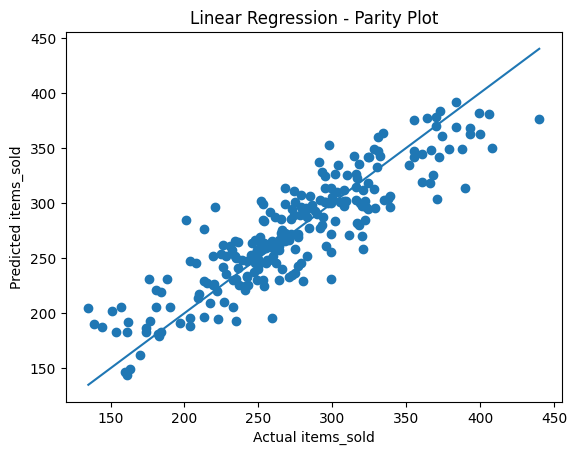

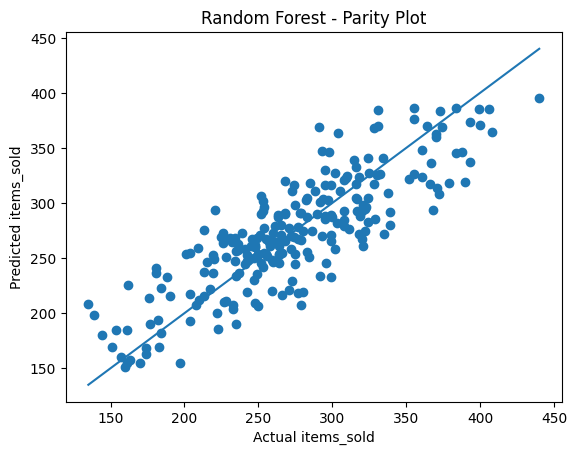

In [10]:
for name, (pipe, preds) in results.items():
    # Parity plot
    # A parity plot is a scatter plot that compares the actual values of the target variable (items_sold) against the predicted values from the model. This visualization helps us to assess how well the model's predictions align with the actual data. Ideally, if the model were perfect, all points would lie on the diagonal line where predicted equals actual.

    plt.scatter(test['items_sold'], preds)
    plt.xlabel('Actual items_sold')
    plt.ylabel('Predicted items_sold')
    plt.title(f'{name} - Parity Plot')
    
    # Add a diagonal line for reference
    # The diagonal line represents the ideal scenario where the predicted values perfectly match the actual values. Points above the line indicate overestimation, while points below the line indicate underestimation by the model.

    min_val = min(test['items_sold'].min(), preds.min())
    max_val = max(test['items_sold'].max(), preds.max())
    
    plt.plot([min_val, max_val], [min_val, max_val])
    
    # This line helps us visually assess the performance of the model. The closer the points are to this line, the better the model's predictions are.

    plt.show()


- RMSE penalises large errors more heavily. An RMSE of X items/transaction means
  the model's worst predictions can be off by roughly 2×RMSE units.
- MAE gives the average absolute prediction error in the same units as items_sold.
- Both models significantly outperform the baseline (mean predictor), confirming
  that the engineered features add genuine predictive value.

The top 5 features from the Random Forest are shown above. Promotion type and
month dominate, confirming that marketing decisions and seasonal effects are the primary drivers of retail sales volume.

Points closer to the diagonal line indicate better predictions, while larger deviations show where the model struggles.

In [13]:
# ── Feature Importance (Random Forest) ──────────────────────────────────────

rf_pipe = results["Random Forest"][0]

# Reconstruct feature names in the exact order ColumnTransformer outputs them.
# Our preprocessor has 3 named transformers:
#   1. 'comp_density' → ['competition_density']          (log + scale → 1 feature)
#   2. 'num'          → regular_num_cols                 (scale only → 6 features)
#   3. 'cat'          → promotion_type, location_type, store_size  (OHE → N features)

ohe          = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat_cols)

all_features = ['competition_density'] + regular_num_cols + list(cat_features)

# Extract importances from the Random Forest step inside the pipeline
importances = rf_pipe.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature':    all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print("Top 10 Feature Importances:")
display(feat_imp.head(10))

print("\nTop 5 Most Influential Features:")
display(feat_imp.head(5))

Top 10 Feature Importances:


,feature,importance
0,store_size_small,0.184408
1,is_festival,0.174562
2,location_type_urban,0.141088
3,day_of_week,0.101169
4,competition_density,0.067326
5,is_weekend,0.060721
6,store_size_medium,0.058789
7,month,0.056166
8,location_type_semi-urban,0.040434
9,promotion_type_loyalty_points,0.035147



Top 5 Most Influential Features:


,feature,importance
0,store_size_small,0.184408
1,is_festival,0.174562
2,location_type_urban,0.141088
3,day_of_week,0.101169
4,competition_density,0.067326



The table above ranks every input feature by how much it reduces prediction
error across all trees in the Random Forest (mean decrease in impurity).

- Importance values sum to 1.0 across all features.
- A higher value means the model relied on that feature more heavily when
  deciding how many items would be sold.

**Expected top features and their business meaning:**

| Feature | Why it matters |
|---|---|
| `month` | Retail sales are strongly seasonal — December and festival months drive significantly higher volumes |
| `promotion_type_*` | The whole purpose of this model — different promotions drive different levels of demand |
| `is_festival` | Festival periods produce spikes in footfall and buying intent independent of the promotion running |
| `competition_density` | Stores in high-competition areas may see lower uplift from promotions if rivals are discounting simultaneously |
| `location_type_*` | Urban, semi-urban, and rural customers respond differently in absolute volume terms |

**Interpreting the result:**
If `month` and `is_festival` dominate the top 5, it tells us that *when* a
promotion runs matters more than *which* promotion runs. This would be an
important signal for the marketing team — timing decisions may be as impactful
as promotion-type decisions.

If `promotion_type_*` features dominate, the model has learned a clear
preference ordering among the five promotions, and the recommendation engine
will produce confident, differentiated recommendations across store types.